# Titanic Survival Analysis

## Project Objective
This project explores the Titanic passenger dataset to understand the factors associated with passenger survival.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/train.csv")
df.shape

(891, 12)

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [10]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
df["Pclass"].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [12]:
df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [13]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["PassengerId"].duplicated().sum()

np.int64(0)

In [16]:
df[["Age", "Fare", "SibSp", "Parch"]].describe()

,Age,Fare,SibSp,Parch
count,714.000000,891.000000,891.000000,891.000000
mean,29.699118,32.204208,0.523008,0.381594
std,14.526497,49.693429,1.102743,0.806057
min,0.420000,0.000000,0.000000,0.000000
25%,20.125000,7.910400,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,38.000000,31.000000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [17]:
missing = df.isnull().sum()

In [18]:
missing_percentage = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percentage": missing_percentage
}).sort_values("Missing", ascending=False)

,Missing,Percentage
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [19]:
df.groupby("Pclass")["Cabin"].apply(lambda x: x.isnull().sum())

Pclass
1     40
2    168
3    479
Name: Cabin, dtype: int64

In [20]:
df.groupby("Pclass")["Age"].apply(lambda x: x.isnull().sum())

Pclass
1     30
2     11
3    136
Name: Age, dtype: int64

In [21]:
df.groupby("Sex")["Age"].apply(lambda x: x.isnull().sum())

Sex
female     53
male      124
Name: Age, dtype: int64

In [22]:
df["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [23]:
df["Age"].isnull().sum()

np.int64(177)

In [24]:
df["Age"].value_counts().sort_index().head(20)

Age
0.42      1
0.67      1
0.75      2
0.83      2
0.92      1
1.00      7
2.00     10
3.00      6
4.00     10
5.00      4
6.00      3
7.00      3
8.00      4
9.00      8
10.00     2
11.00     4
12.00     1
13.00     2
14.00     6
14.50     1
Name: count, dtype: int64

In [25]:
df.groupby("Pclass")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,186.0,38.233441,14.802856,0.92,27.0,37.0,49.0,80.0
2,173.0,29.877630,14.001077,0.67,23.0,29.0,36.0,70.0
3,355.0,25.140620,12.495398,0.42,18.0,24.0,32.0,74.0


In [26]:
df["Cabin"].value_counts().head(20)

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
C52            2
B28            2
C83            2
F G73          2
D26            2
B58 B60        2
C2             2
E33            2
F4             2
D36            2
Name: count, dtype: int64

In [27]:
df["Cabin"].nunique()

147

In [28]:
df["Cabin"].notnull().sum()

np.int64(204)

In [29]:
df["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [30]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [31]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [32]:
df.loc[df["Embarked"].isnull(), ["PassengerId", "Pclass", "Name", "Sex", "Age", "Fare", "Cabin", "Embarked"]]

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked
61,62,1,"Icard, Miss. Amelie",female,38.0,80.0,B28,NaN
829,830,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,80.0,B28,NaN


In [33]:
df.groupby("Cabin")["Survived"].mean().head(20)

Cabin
A10     0.0
A14     0.0
A16     1.0
A19     0.0
A20     1.0
A23     1.0
A24     0.0
A26     1.0
A31     1.0
A32     0.0
A34     1.0
A36     0.0
A5      0.0
A6      1.0
A7      0.0
B101    1.0
B102    0.0
B18     1.0
B19     0.0
B20     1.0
Name: Survived, dtype: float64

In [34]:
pd.crosstab(df["Sex"], df["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


In [35]:
pd.crosstab(df["Pclass"], df["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [36]:
pd.crosstab(df["Embarked"], df["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


In [37]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [38]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [39]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

## survival rate by sex

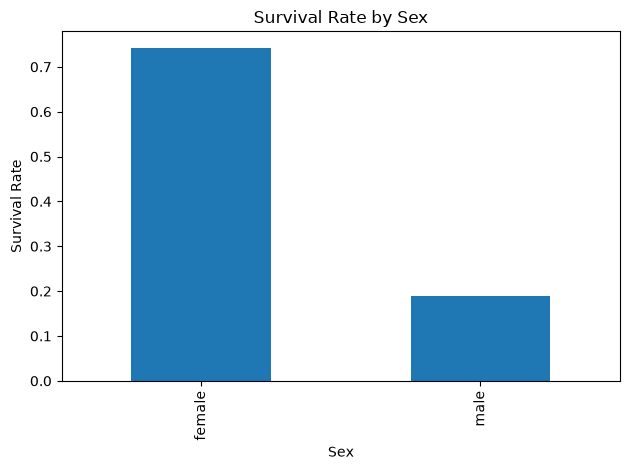

In [99]:
survival_by_sex = df.groupby("Sex")["Survived"].mean()

survival_by_sex.plot(
    kind="bar",
    title="Survival Rate by Sex",
    ylabel="Survival Rate",
    xlabel="Sex"
)

plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_sex.png", dpi=300, bbox_inches="tight")
plt.show()

## Survival Rate by Passenger Class

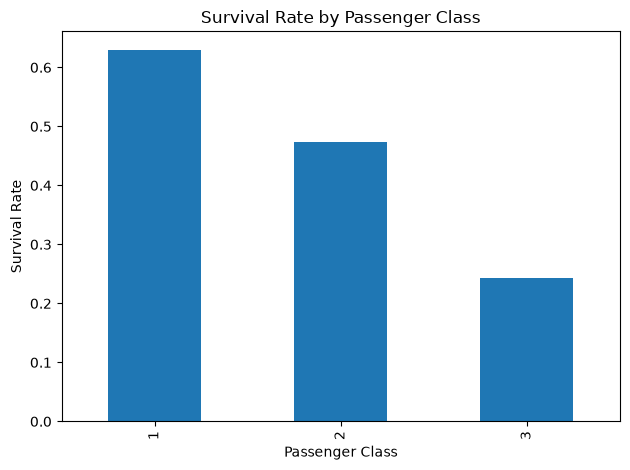

In [98]:
survival_by_class = df.groupby("Pclass")["Survived"].mean()

survival_by_class.plot(
    kind="bar",
    title="Survival Rate by Passenger Class",
    ylabel="Survival Rate",
    xlabel="Passenger Class"
)

plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [42]:
survival_by_sex_class = df.groupby(["Pclass", "Sex"])["Survived"].mean()

survival_by_sex_class

Pclass  Sex   
1       female    0.968085
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: Survived, dtype: float64

## survival rate by sex and passenger class

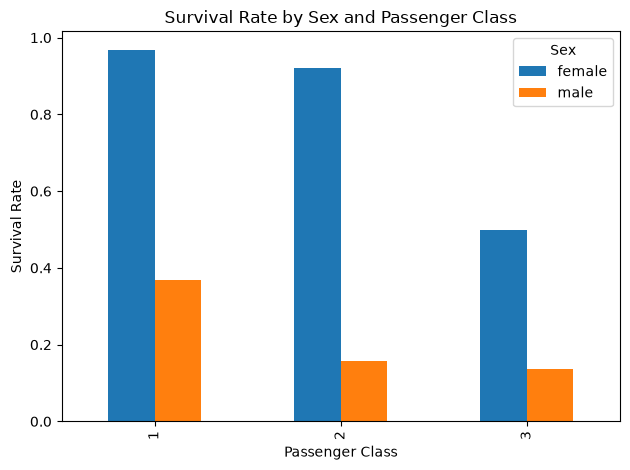

In [97]:
survival_by_sex_class = df.groupby(
    ["Pclass", "Sex"]
)["Survived"].mean().unstack()

survival_by_sex_class.plot(
    kind="bar",
    title="Survival Rate by Sex and Passenger Class",
    ylabel="Survival Rate",
    xlabel="Passenger Class"
)

plt.tight_layout()
plt.savefig("../visuals/survival_rate_by_sex_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
df.groupby("Survived")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [45]:
df.groupby("Survived")["Age"].median()

Survived
0    28.0
1    28.0
Name: Age, dtype: float64

In [46]:
df.groupby(["Pclass", "Sex"])["Age"].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [47]:
df.groupby(["Pclass", "Sex"])["Age"].agg(["count", "median", "mean"])

count  median       mean
Pclass Sex                             
1      female     85    35.0  34.611765
       male      101    40.0  41.281386
2      female     74    28.0  28.722973
       male       99    30.0  30.740707
3      female    102    21.5  21.750000
       male      253    25.0  26.507589

## Data cleaning

In [48]:
df_clean = df.copy()
df_clean["Age"] = df_clean["Age"].fillna(
    df_clean.groupby(["Pclass", "Sex"])["Age"].transform("median")
)

df_clean["Age"].isnull().sum()

np.int64(0)

In [49]:
df_clean[df_clean["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [50]:
df_clean["Embarked"].value_counts()
df_clean["Embarked"] = df_clean["Embarked"].fillna(
    df_clean["Embarked"].mode()[0]
)

In [51]:
df_clean["Embarked"].isnull().sum()

np.int64(0)

In [52]:
df_clean["Embarked"].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [53]:
df_clean["Deck"] = df_clean["Cabin"].str[0]
df_clean["Deck"].value_counts(dropna=False)

Deck
NaN    687
C       59
B       47
D       33
E       32
A       15
F       13
G        4
T        1
Name: count, dtype: int64

In [54]:
df_clean["CabinKnown"] = df_clean["Cabin"].notna()
df_clean["CabinKnown"].value_counts()

CabinKnown
False    687
True     204
Name: count, dtype: int64

In [55]:
df_clean.groupby("CabinKnown")["Survived"].mean()

CabinKnown
False    0.299854
True     0.666667
Name: Survived, dtype: float64

In [56]:
pd.crosstab(df_clean["CabinKnown"], df_clean["Survived"])

Survived,0,1
CabinKnown,,
False,481,206
True,68,136


In [57]:
df_clean.groupby("Deck")["Survived"].agg(["count", "mean"]).sort_values("mean", ascending=False)

,count,mean
Deck,,
D,33,0.757576
E,32,0.750000
B,47,0.744681
F,13,0.615385
C,59,0.593220
G,4,0.500000
A,15,0.466667
T,1,0.000000


In [58]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck           687
CabinKnown       0
dtype: int64

In [59]:
df_clean["Deck"] = df_clean["Deck"].fillna("Unknown")
df_clean["Deck"].isnull().sum()

np.int64(0)

In [60]:
df_clean["Deck"].value_counts()

Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

In [61]:
df_clean.shape

(891, 14)

In [62]:
df_clean.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,CabinKnown
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Unknown,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,True
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Unknown,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Unknown,False


In [63]:
df_clean.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
Deck             0
CabinKnown       0
dtype: int64

In [64]:
df_clean.to_csv("../data/processed/titanic_cleaned.csv", index=False)

In [65]:
df_clean["FamilySize"] = df_clean["SibSp"] + df_clean["Parch"] + 1
df_clean[["SibSp", "Parch", "FamilySize"]].head(10)

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1
5,0,0,1
6,0,0,1
7,3,1,5
8,0,2,3
9,1,0,2


In [66]:
df_clean["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [67]:
df_clean["FamilySize"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

In [68]:
df_clean["FamilySize"].describe()

count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64

In [69]:
df_clean["IsAlone"] = (df_clean["FamilySize"] == 1).astype(int)
df_clean["IsAlone"].value_counts()

IsAlone
1    537
0    354
Name: count, dtype: int64

In [70]:
df_clean[["FamilySize", "IsAlone"]].head(10)

,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1
5,1,1
6,1,1
7,5,0
8,3,0
9,2,0


In [71]:
df_clean.groupby("IsAlone")["Survived"].mean()

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

In [72]:
pd.crosstab(df_clean["IsAlone"], df_clean["Survived"])

Survived,0,1
IsAlone,,
0,175,179
1,374,163


In [73]:
df_clean.groupby(["Sex", "IsAlone"])["Survived"].mean()

Sex     IsAlone
female  0          0.712766
        1          0.785714
male    0          0.271084
        1          0.155718
Name: Survived, dtype: float64

In [74]:
pd.crosstab(
    [df_clean["Sex"], df_clean["IsAlone"]],
    df_clean["Survived"]
)

Survived          0    1
Sex    IsAlone          
female 0         54  134
       1         27   99
male   0        121   45
       1        347   64

In [75]:
df_clean.groupby(["Pclass", "IsAlone"])["Survived"].mean()

Pclass  IsAlone
1       0          0.728972
        1          0.532110
2       0          0.637500
        1          0.346154
3       0          0.299401
        1          0.212963
Name: Survived, dtype: float64

In [76]:
pd.crosstab(
    [df_clean["Pclass"], df_clean["IsAlone"]],
    df_clean["Survived"]
)

Survived          0   1
Pclass IsAlone         
1      0         29  78
       1         51  58
2      0         29  51
       1         68  36
3      0        117  50
       1        255  69

In [77]:
df_clean["Title"] = df_clean["Name"].str.extract(r",\s*([^.]*)\.")[0].str.strip()

In [78]:
df_clean["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [79]:
common_titles = ["Mr", "Miss", "Mrs", "Master"]

df_clean["TitleGroup"] = df_clean["Title"].where(
    df_clean["Title"].isin(common_titles),
    "Rare"
)

df_clean["TitleGroup"].value_counts()

TitleGroup
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [80]:
df_clean.groupby("TitleGroup")["Survived"].mean().sort_values(ascending=False)

TitleGroup
Mrs       0.792000
Miss      0.697802
Master    0.575000
Rare      0.444444
Mr        0.156673
Name: Survived, dtype: float64

In [81]:
pd.crosstab(df_clean["TitleGroup"], df_clean["Survived"])

Survived,0,1
TitleGroup,,
Master,17,23
Miss,55,127
Mr,436,81
Mrs,26,99
Rare,15,12


In [82]:
df_clean.groupby("TitleGroup")["Age"].agg(["count", "median", "mean"])

,count,median,mean
TitleGroup,,,
Master,40,4.0,6.616750
Miss,182,21.5,21.865385
Mr,517,28.0,31.339458
Mrs,125,35.0,34.804000
Rare,27,44.0,42.296296


In [83]:
df_clean.groupby("FamilySize")["Survived"].agg(["count", "mean"])

,count,mean
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


In [84]:
df_clean.groupby(["Pclass", "FamilySize"])["Survived"].agg(["count", "mean"])

count      mean
Pclass FamilySize                 
1      1             109  0.532110
       2              70  0.728571
       3              24  0.750000
       4               7  0.714286
       5               2  1.000000
       6               4  0.500000
2      1             104  0.346154
       2              34  0.529412
       3              31  0.677419
       4              13  0.769231
       5               1  1.000000
       6               1  1.000000
3      1             324  0.212963
       2              57  0.350877
       3              47  0.425532
       4               9  0.666667
       5              12  0.000000
       6              17  0.000000
       7              12  0.333333
       8               6  0.000000
       11              7  0.000000

In [85]:
df_clean.groupby("Survived")["Age"].agg(["count", "median", "mean"])

,count,median,mean
Survived,,,
0,549,25.0,29.737705
1,342,27.0,28.108684


In [86]:
df_clean["Age"].describe()

count    891.000000
mean      29.112424
std       13.304424
min        0.420000
25%       21.500000
50%       26.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

In [87]:
df_clean["Age"].value_counts().sort_index().head(20)

Age
0.42      1
0.67      1
0.75      2
0.83      2
0.92      1
1.00      7
2.00     10
3.00      6
4.00     10
5.00      4
6.00      3
7.00      3
8.00      4
9.00      8
10.00     2
11.00     4
12.00     1
13.00     2
14.00     6
14.50     1
Name: count, dtype: int64

In [88]:
age_bins = [0, 12, 17, 30, 45, 60, float("inf")]
age_labels = ["Child", "Teen", "Young Adult", "Adult", "Older Adult", "Senior"]

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=age_bins,
    labels=age_labels,
    include_lowest=True
)

In [89]:
df_clean["AgeGroup"].value_counts().sort_index()

AgeGroup
Child           69
Teen            44
Young Adult    443
Adult          232
Older Adult     81
Senior          22
Name: count, dtype: int64

In [90]:
df_clean.groupby("AgeGroup", observed=True)["Survived"].agg(["count", "mean"])

,count,mean
AgeGroup,,
Child,69,0.579710
Teen,44,0.477273
Young Adult,443,0.322799
Adult,232,0.431034
Older Adult,81,0.407407
Senior,22,0.227273


In [91]:
df_clean.groupby(["AgeGroup", "Sex"], observed=True)["Survived"].agg(["count", "mean"])

count      mean
AgeGroup    Sex                    
Child       female     32  0.593750
            male       37  0.567568
Teen        female     23  0.826087
            male       21  0.095238
Young Adult female    147  0.700680
            male      296  0.135135
Adult       female     82  0.804878
            male      150  0.226667
Older Adult female     27  0.851852
            male       54  0.185185
Senior      female      3  1.000000
            male       19  0.105263

In [92]:
df_clean["Age"].isna().sum()

np.int64(0)

## survival rate by age group

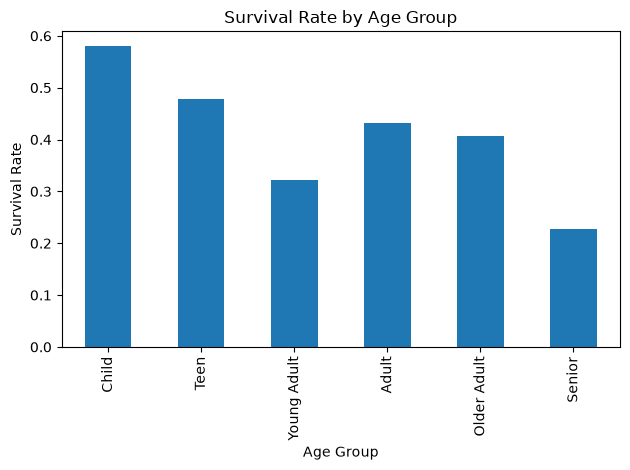

In [101]:
survival_by_age = df_clean.groupby(
    "AgeGroup", observed=True
)["Survived"].mean()

survival_by_age.plot(
    kind="bar",
    title="Survival Rate by Age Group",
    ylabel="Survival Rate",
    xlabel="Age Group"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival rate by family size

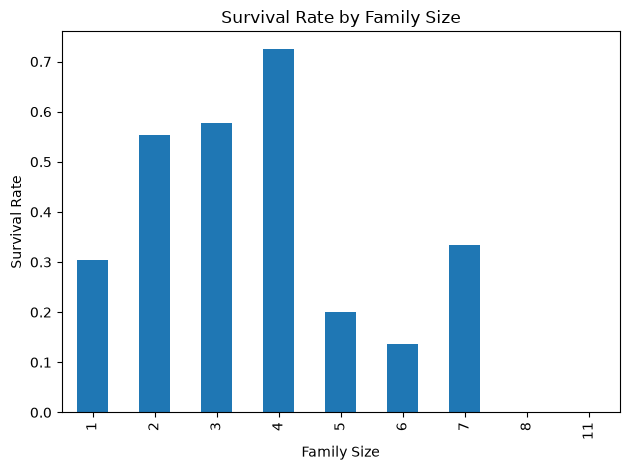

In [102]:
survival_by_family_size = df_clean.groupby("FamilySize")["Survived"].mean()

survival_by_family_size.plot(
    kind="bar",
    title="Survival Rate by Family Size",
    ylabel="Survival Rate",
    xlabel="Family Size"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_family_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival rate by cabin

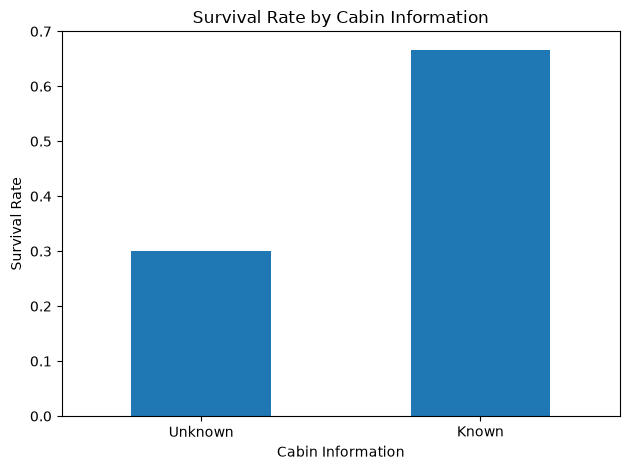

In [103]:
survival_by_cabin = df_clean.groupby("CabinKnown")["Survived"].mean()

survival_by_cabin.plot(
    kind="bar",
    title="Survival Rate by Cabin Information",
    ylabel="Survival Rate",
    xlabel="Cabin Information"
)

plt.xticks([0, 1], ["Unknown", "Known"], rotation=0)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_cabin_known.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival rate by deck 

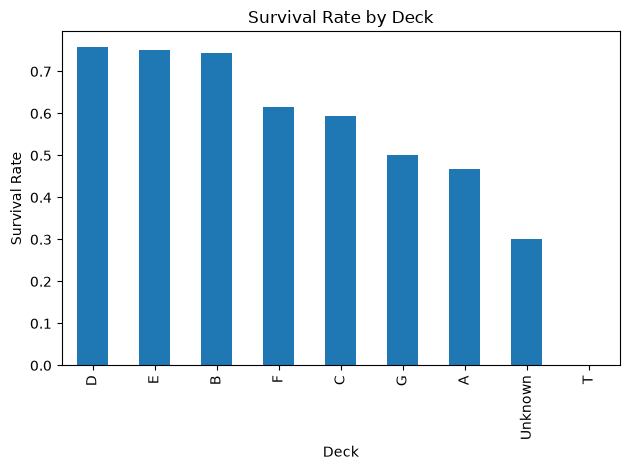

In [104]:
survival_by_deck = df_clean.groupby("Deck")["Survived"].mean().sort_values(ascending=False)

survival_by_deck.plot(
    kind="bar",
    title="Survival Rate by Deck",
    ylabel="Survival Rate",
    xlabel="Deck"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_deck.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival rate by embarked

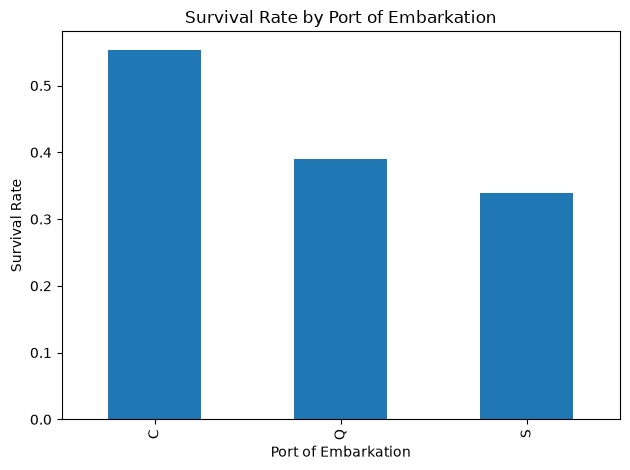

In [105]:
survival_by_embarked = df_clean.groupby("Embarked")["Survived"].mean()

survival_by_embarked.plot(
    kind="bar",
    title="Survival Rate by Port of Embarkation",
    ylabel="Survival Rate",
    xlabel="Port of Embarkation"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_embarked.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival rate by title

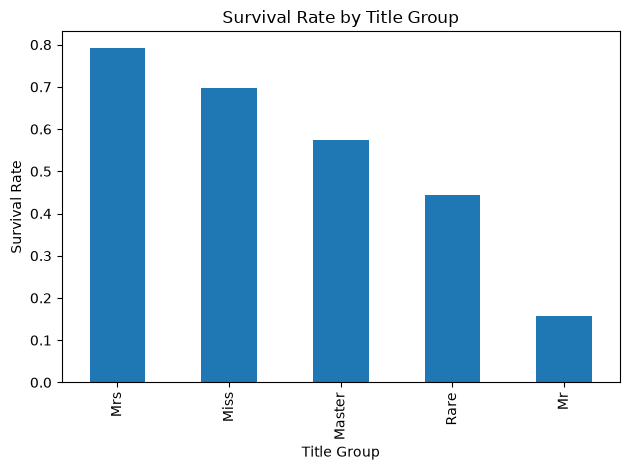

In [106]:
survival_by_title = df_clean.groupby("TitleGroup")["Survived"].mean().sort_values(ascending=False)

survival_by_title.plot(
    kind="bar",
    title="Survival Rate by Title Group",
    ylabel="Survival Rate",
    xlabel="Title Group"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_title_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival by age sex

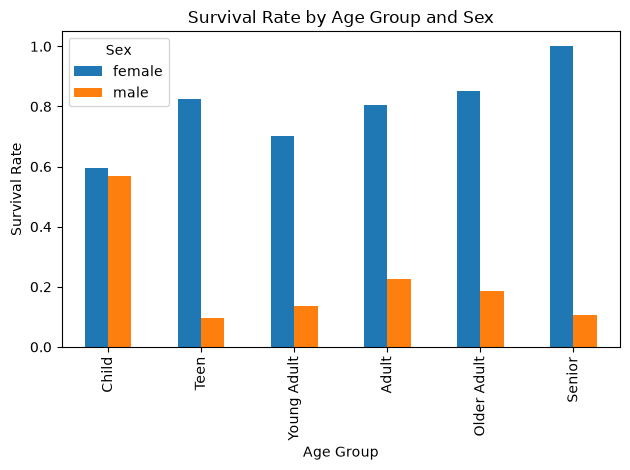

In [107]:
survival_by_age_sex = df_clean.groupby(
    ["AgeGroup", "Sex"], observed=True
)["Survived"].mean().unstack()

survival_by_age_sex.plot(
    kind="bar",
    title="Survival Rate by Age Group and Sex",
    ylabel="Survival Rate",
    xlabel="Age Group"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_age_and_sex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival by class family

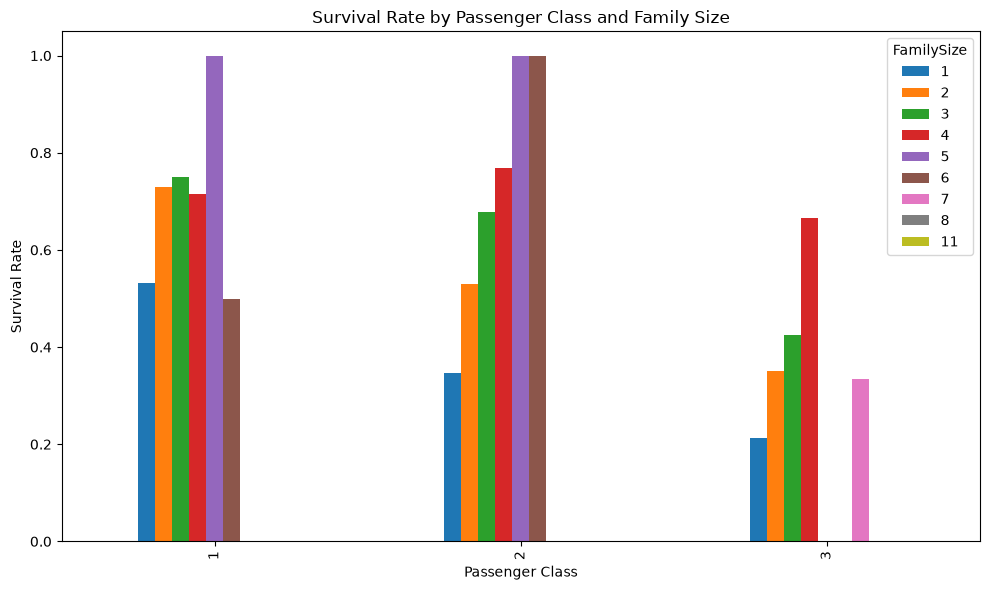

In [108]:
survival_by_class_family = df_clean.groupby(
    ["Pclass", "FamilySize"]
)["Survived"].mean().unstack()

survival_by_class_family.plot(
    kind="bar",
    figsize=(10, 6),
    title="Survival Rate by Passenger Class and Family Size",
    ylabel="Survival Rate",
    xlabel="Passenger Class"
)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_class_and_family_size.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## survival by sex alone

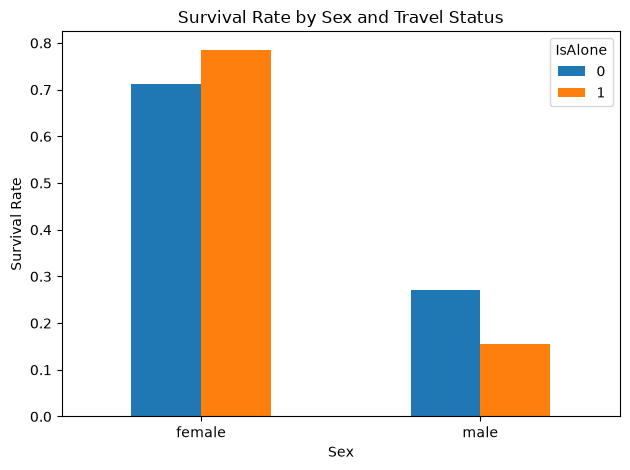

In [109]:
survival_by_sex_alone = df_clean.groupby(
    ["Sex", "IsAlone"]
)["Survived"].mean().unstack()

survival_by_sex_alone.plot(
    kind="bar",
    title="Survival Rate by Sex and Travel Status",
    ylabel="Survival Rate",
    xlabel="Sex"
)

plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "../visuals/survival_rate_by_sex_and_alone.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()